## 1. Flip
* Definition: Horizontally or vertically mirroring an image to create mirror-image variants.
* Use Cases:
    * Image classification and object detection where orientation doesn't alter after semantic meaning.
* Pros:
    * Increases dataset diversity instantly with minimal computational cost.
* Cons:
    * Unsuitable for text, digits, or asymmetric objects where flipping changes the meaning (e.g., 'b' vs 'd').

### Visualizing Flip Augmentation

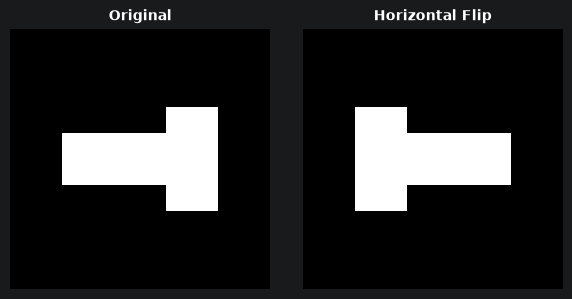

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate an asymmetric image (e.g., an arrow pointing right)
img = np.zeros((10, 10))
img[4:6, 2:8] = 1
img[3:7, 6:8] = 1

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(np.fliplr(img), cmap='gray')
axes[1].set_title("Horizontal Flip", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. Rotate
* Definiton: Turning an image by a random or fixed degree around its central coordinate axis.
* Use Cases:
    * Aerial mapping, satellite imagery, and object detection across varied camera angles.
* Pros:
    * Trains models to become invariant to rotational changes.
* Cons:
    * Can introduce empty corner artifacts or require interpolation that blurs fine pixels.

### Visualizing Rotation Augmentation

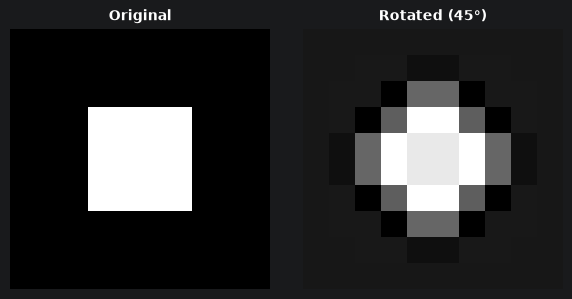

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

img = np.zeros((10, 10))
img[3:7, 3:7] = 1

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(rotate(img, angle=45, reshape=False), cmap='gray')
axes[1].set_title("Rotated (45°)", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Crop
* Definition: Extracting a specific sub-region or randomly zooming into portions of an images
* Use Cases:
    * Object localization, multi-scale training, and removing background clutter.
* Pros:
    * Forces models to focus on local features and partial object structures.
* Cons:
    * Risk of accidentally cropping out the primary object of interest entirely.

### Visualizing Crop Augmentation

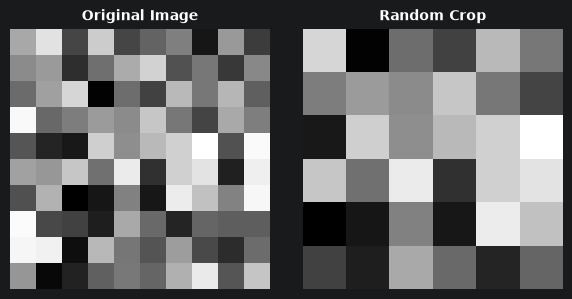

In [3]:
import numpy as np
import matplotlib.pyplot as plt

img = np.random.rand(10, 10)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img[2:8, 2:8], cmap='gray')
axes[1].set_title("Random Crop", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Resize
* Definition: Scaling image height and width dimensions to a uniform size.
* Use Cases:
    * Standardizing input tensor shapes required by neural network batching.
* Pros:
    * Ensures consistent tensor dimensions across all samples in a dataset.
* Cons:
    * Can distort aspect ratios or degrade high-frequency details if downscaled too aggressively.

### Visualizing Resize Augmentation

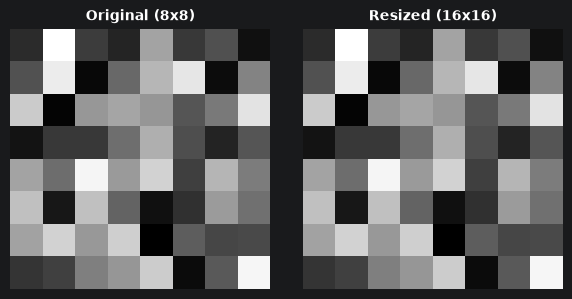

In [4]:
import numpy as np
import matplotlib.pyplot as plt

img = np.random.rand(8, 8)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray', interpolation='nearest')
axes[0].set_title("Original (8x8)", fontsize=10, fontweight='bold')
axes[0].axis('off')

# Simple pixel block replication for illustration
axes[1].imshow(np.kron(img, np.ones((2, 2))), cmap='gray', interpolation='nearest')
axes[1].set_title("Resized (16x16)", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Random Erasing
* Definition: Selectively masking out random rectangular patches of an image with constant values or noise.
* Use Cases:
    * Preventing overfitting and forcing models to look at holistic object features.
* Pros:
    * Improves generalization by discouraging reliance on single visual cues.
* Cons:
    * Can obscure vital features if the erased patch covers a small, critical object.

### Visualizing Random Erasing

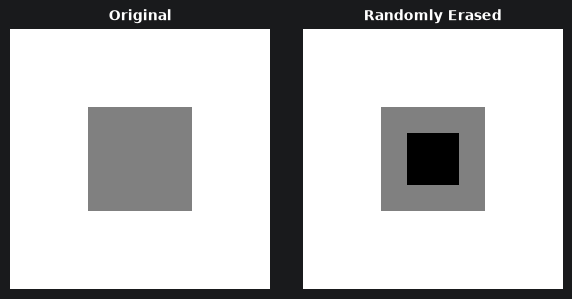

In [5]:
import numpy as np
import matplotlib.pyplot as plt

img = np.ones((10, 10))
img[3:7, 3:7] = 0.5

img_erased = img.copy()
img_erased[4:6, 4:6] = 0.0 # Erased patch

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_erased, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Randomly Erased", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Color Jitter
* Definition: Randomly tweaking brightness, contrast, saturation, and hue properties of an image.
* Use Cases:
    * Making models robust to varying real-world lighting conditions and camera sensors.
* Pros:
    * Boosts performance across diverse environments and atmospheric settings.
* Cons:
    * Extreme adjustments can yield unrealistic, uninformative color distributions.

### Visualizing Color Jitter

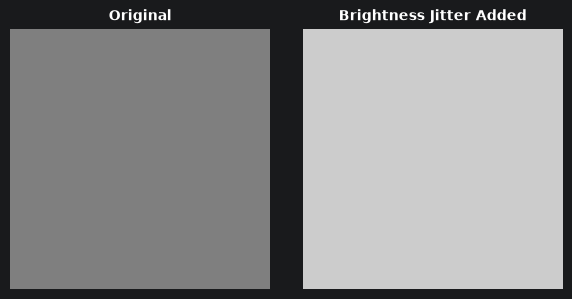

In [6]:
import numpy as np
import matplotlib.pyplot as plt

img = np.ones((10, 10, 3)) * 0.5
img_bright = np.clip(img + 0.3, 0, 1) # Increased brightness

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img)
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_bright)
axes[1].set_title("Brightness Jitter Added", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 7. Blur
* Definition: Applying smoothing filters (such as Gaussian filters) to soften fine details and sharp edges.
* Use Cases:
    * Simulating out-of-focus camera shots, low-resolution capture devices, or motion blur.
* Pros:
    * Enhances model resilience against blurry or degraded real-world imagery.
* Cons:
    * Destroys high-frequency textures required for fine-grained classification tasks.

### Visualizing Blur Augmentation

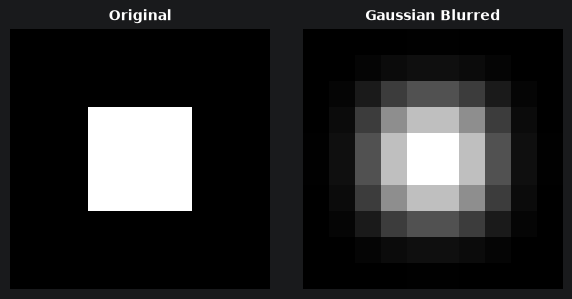

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

img = np.zeros((10, 10))
img[3:7, 3:7] = 1

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(gaussian_filter(img, sigma=1), cmap='gray')
axes[1].set_title("Gaussian Blurred", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 8. Noise
* Definition: Adding random pixel-level fluctuations (e.g., Gaussian or salt-and-pepper noise) to an image.
* Use Cases:
    * Simulating electronic sensor grain, transmission interference, or atmospheric dust.
* Pros:
    * Increases network robustness against adversarial corruption or noisy data inputs.
* Cons:
    * Excess noise can completely mask underlying patterns and harm training.

### Visualizing Noise Augmentation

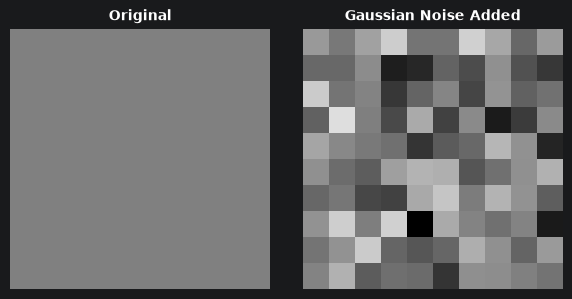

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
img = np.ones((10, 10)) * 0.5
noise = np.random.normal(0, 0.2, (10, 10))
img_noisy = np.clip(img + noise, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Gaussian Noise Added", fontsize=10, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 9. MixUp
* Definition: Linearly blending two random training images and their respective target labels together ($\tilde{x} = \lambda x_i + (1-\lambda)x_j$).
* Use Cases:
    * Regularizing deep neural networks to yield smoother decision boundaries.
* Pros:
    * Reduces memorization of noisy labels and improves calibration.
* Cons:
    * Generates unnatural composite images that lack distinct semantic separation.

### Visualizing MixUp Concept

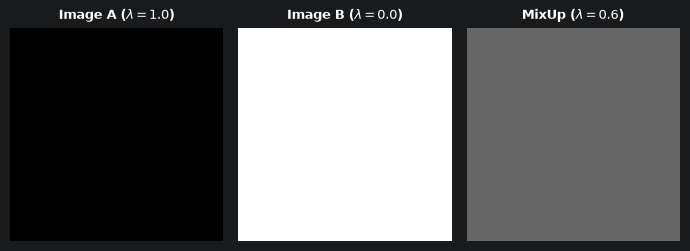

In [11]:
import numpy as np
import matplotlib.pyplot as plt

img1 = np.zeros((10, 10))
img2 = np.ones((10, 10))
mixed = 0.6 * img1 + 0.4 * img2

fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(r"Image A ($\lambda=1.0$)", fontsize=9, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(r"Image B ($\lambda=0.0$)", fontsize=9, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(mixed, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(r"MixUp ($\lambda=0.6$)", fontsize=9, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 10. CutMix
* Definition: Cutting a patch from one image and pasting it onto another, scaling the target label proportional to the patch area.
* Use Cases:
    * Object detection and image classification where localized regional features matter.
* Pros:
    * Retains local object details while providing mixed regularization benefits.
* Cons:
    * Requires bounding box or patch coordinate calculations.

### Visualizing CutMix Concept

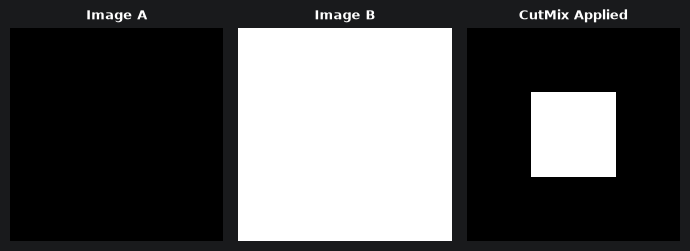

In [12]:
import numpy as np
import matplotlib.pyplot as plt

img1 = np.zeros((10, 10))
img2 = np.ones((10, 10))
cutmixed = img1.copy()
cutmixed[3:7, 3:7] = img2[3:7, 3:7]

fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Image A", fontsize=9, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Image B", fontsize=9, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(cutmixed, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("CutMix Applied", fontsize=9, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 11. Mosaic
* Definition: Stitching four distinct training images together into a single combined composite grid layout.
* Use Cases:
    * Training real-time object detection models (like YOLO variants) with varied contexts.
* Pros:
    * Exposes the model to multiple scales and diverse backgrounds in a single training step.
* Cons:
    * Distorts original aspect ratios and scales; increases data pipeline complexity.

### Visualizing Mosaic Augmentation

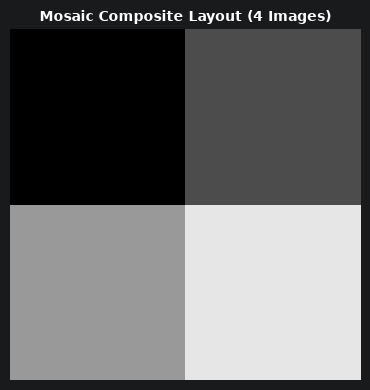

In [13]:
import numpy as np
import matplotlib.pyplot as plt

q1 = np.zeros((5, 5))
q2 = np.ones((5, 5)) * 0.3
q3 = np.ones((5, 5)) * 0.6
q4 = np.ones((5, 5)) * 0.9

top = np.hstack((q1, q2))
bottom = np.hstack((q3, q4))
mosaic = np.vstack((top, bottom))

plt.figure(figsize=(4, 4))
plt.imshow(mosaic, cmap='gray', vmin=0, vmax=1)
plt.title("Mosaic Composite Layout (4 Images)", fontsize=10, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()